In [3]:
import subprocess

# Cluster using mmseqs2
# mmseqs easy-cluster input.fa cluster-results tmp --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1

coverage_threshold = 0.4
min_seq_id = 0.3

input_file = "../../data-collection/positive-SP.fasta"
output_dir = "./output"
subprocess.run(f"rm -rf positive \
                && mkdir positive \
                && cd positive \
                && mmseqs easy-cluster {input_file} cluster-results {output_dir} --min-seq-id {min_seq_id} -c {coverage_threshold} --cov-mode 0 --cluster-mode 1 \
                && cd ..",
                               shell=True,
                               text=True)

Create directory ./output
easy-cluster ../../data-collection/positive-SP.fasta cluster-results ./output --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1 

MMseqs Version:                     	18-8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.4
Coverage mode                       	0
Compositional bias                  	1
Compositional bias scale            	1
Diagonal scoring                    	true
Exact k-mer mat

CompletedProcess(args='rm -rf positive                 && mkdir positive                 && cd positive                 && mmseqs easy-cluster ../../data-collection/positive-SP.fasta cluster-results ./output --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1                 && cd ..', returncode=0)

In [4]:

input_file = "../../data-collection/negative-SP.fasta"
subprocess.run(f"rm -rf negative && mkdir negative && cd negative && mmseqs easy-cluster {input_file} cluster-results {output_dir} --min-seq-id {min_seq_id} -c {coverage_threshold} --cov-mode 0 --cluster-mode 1 && cd ..",
                               shell=True,
                               text=True)

Create directory ./output
easy-cluster ../../data-collection/negative-SP.fasta cluster-results ./output --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1 

MMseqs Version:                     	18-8cc5c
Substitution matrix                 	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix            	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                         	4
k-mer length                        	0
Target search mode                  	0
k-score                             	seq:2147483647,prof:2147483647
Alphabet size                       	aa:21,nucl:5
Max sequence length                 	65535
Max results per query               	20
Split database                      	0
Split mode                          	2
Split memory limit                  	0
Coverage threshold                  	0.4
Coverage mode                       	0
Compositional bias                  	1
Compositional bias scale            	1
Diagonal scoring                    	true
Exact k-mer mat

CompletedProcess(args='rm -rf negative && mkdir negative && cd negative && mmseqs easy-cluster ../../data-collection/negative-SP.fasta cluster-results ./output --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1 && cd ..', returncode=0)

In [5]:
import pandas as pd

In [8]:
negative_tsv = "../data-collection/negative-SP.tsv"

neg_df = pd.read_csv(negative_tsv, sep='\t', names=['ID', 'Taxa','kingdom','length','site'])
neg_df

,ID,Taxa,kingdom,length,site
0,Q6YN16,Homo sapiens,Metazoa,418,False
1,Q9UHK6,Homo sapiens,Metazoa,382,False
2,A3KMH1,Homo sapiens,Metazoa,1905,False
3,O75874,Homo sapiens,Metazoa,414,False
4,Q9NTK1,Homo sapiens,Metazoa,212,False
...,...,...,...,...,...
20610,C0HMD7,Homo sapiens,Metazoa,151,False
20611,P40166,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,100,False
20612,Q02749,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,293,False
20613,P53307,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,113,False


In [9]:
positive_tsv = "../data-collection/positive-SP.tsv"

df = pd.read_csv(positive_tsv, sep='\t', names=['ID', 'Taxa','kingdom','length','site'])
df

,ID,Taxa,kingdom,length,site
0,O00300,Homo sapiens,Metazoa,401,21
1,O00478,Homo sapiens,Metazoa,584,29
2,O00748,Homo sapiens,Metazoa,559,26
3,O14763,Homo sapiens,Metazoa,440,55
4,O43155,Homo sapiens,Metazoa,660,35
...,...,...,...,...,...
2933,I6RA76,Scolopendra mutilans,Metazoa,64,18
2934,P10976,Spinacia oleracea,Viridiplantae,117,26
2935,P91629,Drosophila miranda,Metazoa,126,16
2936,Q95VP2,Epiphyas postvittana,Metazoa,161,20


In [10]:
negative_clustered = "./negative/cluster-results_cluster.tsv"

neg_clus_df = pd.read_csv(negative_clustered, sep='\t',names = ['cluster','sequence'])
reps = neg_clus_df['cluster'].unique()


In [11]:
neg_filtered = neg_df.loc[neg_df['ID'].isin(reps)]
neg_filtered

,ID,Taxa,kingdom,length,site
0,Q6YN16,Homo sapiens,Metazoa,418,False
4,Q9NTK1,Homo sapiens,Metazoa,212,False
7,P50542,Homo sapiens,Metazoa,639,False
11,P49419,Homo sapiens,Metazoa,539,False
12,Q9Y3I1,Homo sapiens,Metazoa,522,False
...,...,...,...,...,...
20610,C0HMD7,Homo sapiens,Metazoa,151,False
20611,P40166,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,100,False
20612,Q02749,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,293,False
20613,P53307,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,113,False


In [12]:
positive_clustered = "./positive/cluster-results_cluster.tsv"

pos_clus_df = pd.read_csv(positive_clustered, sep='\t',names = ['cluster','sequence'])
reps = pos_clus_df['cluster'].unique()


In [13]:
pos_filtered = df.loc[df['ID'].isin(reps)]
pos_filtered

,ID,Taxa,kingdom,length,site
4,O43155,Homo sapiens,Metazoa,660,35
6,O43866,Homo sapiens,Metazoa,347,19
8,O75629,Homo sapiens,Metazoa,220,31
9,O94985,Homo sapiens,Metazoa,981,28
17,P01579,Homo sapiens,Metazoa,166,23
...,...,...,...,...,...
2927,Q39962,Hevea brasiliensis,Viridiplantae,238,31
2928,Q7M3V1,Chelonus sp. nr. curvimaculatus,Metazoa,246,20
2929,Q8MMH5,Pimpla hypochondriaca,Metazoa,61,20
2933,I6RA76,Scolopendra mutilans,Metazoa,64,18


In [14]:
merged = pd.concat([pos_filtered,neg_filtered])
actualmerged = merged.copy(deep="True")
merged.loc[merged['site'] != 0, 'site'] = 1
merged


,ID,Taxa,kingdom,length,site
4,O43155,Homo sapiens,Metazoa,660,1
6,O43866,Homo sapiens,Metazoa,347,1
8,O75629,Homo sapiens,Metazoa,220,1
9,O94985,Homo sapiens,Metazoa,981,1
17,P01579,Homo sapiens,Metazoa,166,1
...,...,...,...,...,...
20610,C0HMD7,Homo sapiens,Metazoa,151,0
20611,P40166,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,100,0
20612,Q02749,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,293,0
20613,P53307,Saccharomyces cerevisiae (strain ATCC 204508 /...,Fungi,113,0


In [15]:
merged.tail(40)

,ID,Taxa,kingdom,length,site
20553,Q9URV3,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,296,0
20554,Q10296,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,138,0
20555,Q9UTA6,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,303,0
20556,O13758,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,361,0
20557,O13859,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,285,0
20558,O42647,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,188,0
20559,O60057,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,411,0
20561,Q09902,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,85,0
20562,Q7M2P1,Sus scrofa,Metazoa,76,0
20563,Q9UT17,Schizosaccharomyces pombe (strain 972 / ATCC 2...,Fungi,328,0


In [16]:
from sklearn.model_selection  import train_test_split

In [17]:
X = merged.drop('site', axis=1).to_numpy()
y = merged['site'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y

array([1, 1, 1, ..., 0, 0, 1], shape=(10028,))

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

X = pd.DataFrame(X, columns=['ID', 'Taxa', 'kingdom', 'length'])


preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_id', TfidfVectorizer(), 'ID'),
        ('tfidf_taxa', TfidfVectorizer(), 'Taxa'),
        ('tfidf_kingdom', TfidfVectorizer(), 'kingdom')
    ]
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(kernel='linear', C=1, random_state=42))
])

# y = np.where(y != 0, 1, y)
# y
scores = cross_val_score(clf, X, y, cv=5)
print("CV scores:", scores)
print("Mean accuracy:", scores.mean())


CV scores: [0.80109671 0.87587238 0.90079761 0.77107232 0.74064838]
Mean accuracy: 0.8178974796309326


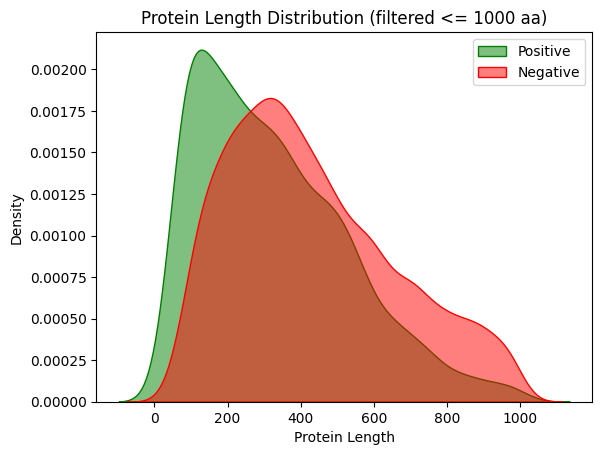

In [19]:
max_length = 1000
subset = merged[merged['length'] <= max_length]

sns.kdeplot(subset[subset['site']==1]['length'], 
            label='Positive', color='green', fill=True, alpha=0.5)
sns.kdeplot(subset[subset['site']==0]['length'], 
            label='Negative', color='red', fill=True, alpha=0.5)

plt.xlabel('Protein Length')
plt.ylabel('Density')
plt.title('Protein Length Distribution (filtered <= 1000 aa)')
plt.legend()
plt.show()


/var/folders/fv/hc0ld44x7nsbxtxk14c7fbyh0000gn/T/ipykernel_86298/3545085021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='site', y='length', data=subset, palette={'0':'red', '1':'green'})


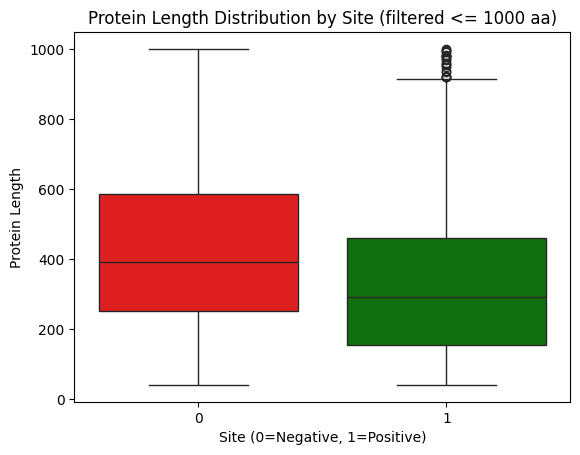

In [20]:
subset = merged[merged['length'] <= 1000]

sns.boxplot(x='site', y='length', data=subset, palette={'0':'red', '1':'green'})
plt.xlabel('Site (0=Negative, 1=Positive)')
plt.ylabel('Protein Length')
plt.title('Protein Length Distribution by Site (filtered <= 1000 aa)')
plt.show()



In [38]:
merged.head()


,ID,Taxa,kingdom,length,site
4,O43155,Homo sapiens,Metazoa,660,1
6,O43866,Homo sapiens,Metazoa,347,1
8,O75629,Homo sapiens,Metazoa,220,1
9,O94985,Homo sapiens,Metazoa,981,1
17,P01579,Homo sapiens,Metazoa,166,1


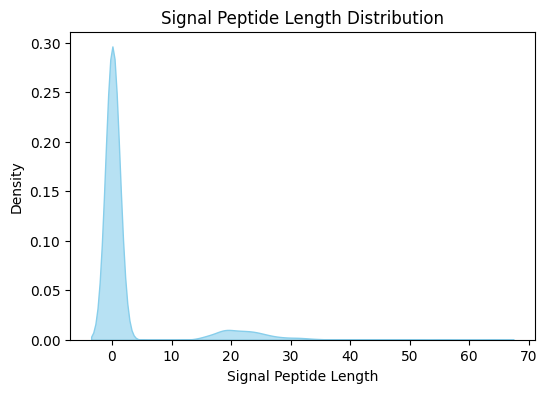

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.kdeplot(actualmerged['site'], fill=True, color='skyblue', alpha=0.6)
plt.xlabel('Signal Peptide Length')
plt.ylabel('Density')
plt.title('Signal Peptide Length Distribution')
plt.show()
...

In [3]:
from Bio import SeqIO
import pandas as pd

# Load your TSV file that has 'ID' and 'site' columns
# Example:
# ID     site
# O43155 35
# O43866 19
# ...
positive_tsv = "../data-collection/positive-SP.tsv"

tsv = pd.read_csv(positive_tsv, sep='\t', names=['ID', 'Taxa','kingdom','length','site'])

# Load protein sequences from FASTA (positive proteins)
fasta_records = {record.id.split("|")[0]: str(record.seq) for record in SeqIO.parse("./positive/cluster-results_rep_seq.fasta", "fasta")}

# Extract SP sequences (from start until cleavage site)
sp_sequences = []
for _, row in tsv.iterrows():
    prot_id = row['ID']
    if prot_id in fasta_records:
        seq = fasta_records[prot_id]
        sp_len = int(row['site'])
        sp_seq = seq[:sp_len]
        sp_sequences.append({'ID': prot_id, 'SP_sequence': sp_seq, 'SP_length': sp_len})

sp_df = pd.DataFrame(sp_sequences)
sp_df.head()



,ID,SP_sequence,SP_length
0,O43155,MGLQTTKWPSHGAFFLKSWLIISLGLYSQVSKLLA,35
1,O43866,MALLFSLILAICTRPGFLA,19
2,O75629,MAGLSRGSARALLAALLASTLLALLVSPARG,31
3,O94985,MLRRPAPALAPAARLLLAGLLCGGGVWA,28
4,P01579,MKYTSYILAFQLCIVLGSLGCYC,23


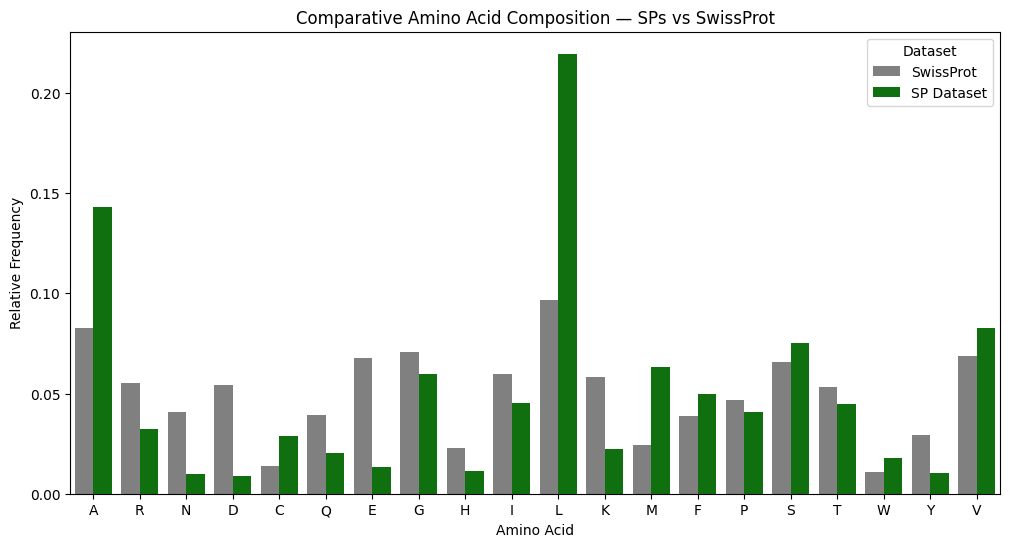

In [4]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all SPs into one string
aa_counts = Counter("".join(sp_df['SP_sequence']))
aa_freq_sp = {aa: count / sum(aa_counts.values()) for aa, count in aa_counts.items()}

# SwissProt composition (from ExPASy)
aa_freq_swissprot = {
    'A': 8.25, 'R': 5.53, 'N': 4.06, 'D': 5.45, 'C': 1.37, 'Q': 3.93, 'E': 6.75,
    'G': 7.07, 'H': 2.27, 'I': 5.96, 'L': 9.66, 'K': 5.84, 'M': 2.42, 'F': 3.86,
    'P': 4.70, 'S': 6.56, 'T': 5.34, 'W': 1.08, 'Y': 2.92, 'V': 6.87
}
aa_freq_swissprot = {aa: val / 100 for aa, val in aa_freq_swissprot.items()}

# Combine into a single DataFrame
aa_df = pd.DataFrame({
    'Amino Acid': list(aa_freq_swissprot.keys()),
    'SwissProt': list(aa_freq_swissprot.values()),
    'SP Dataset': [aa_freq_sp.get(aa, 0) for aa in aa_freq_swissprot.keys()]
})

# Melt for plotting
aa_df_melted = aa_df.melt(id_vars='Amino Acid', var_name='Dataset', value_name='Frequency')

plt.figure(figsize=(12,6))
sns.barplot(data=aa_df_melted, x='Amino Acid', y='Frequency', hue='Dataset', palette=['grey', 'green'])
plt.title('Comparative Amino Acid Composition — SPs vs SwissProt')
plt.ylabel('Relative Frequency')
plt.show()


In [5]:
motifs = []
for _, row in tsv.iterrows():
    prot_id = row['ID']
    site = int(row['site'])
    if prot_id in fasta_records:
        seq = fasta_records[prot_id]
        if site > 13 and len(seq) > site + 2:
            motif = seq[site-13:site+2]
            motifs.append(motif)

# Save motifs for WebLogo
with open("cleavage_motifs.fasta", "w") as f:
    for i, motif in enumerate(motifs):
        f.write(f">motif_{i}\n{motif}\n")

print(f"✅ Saved {len(motifs)} cleavage-site motifs to 'cleavage_motifs.fasta'.")
print("👉 Upload this file to https://weblogo.berkeley.edu/logo.cgi to generate your sequence logo.")


✅ Saved 1094 cleavage-site motifs to 'cleavage_motifs.fasta'.
👉 Upload this file to https://weblogo.berkeley.edu/logo.cgi to generate your sequence logo.


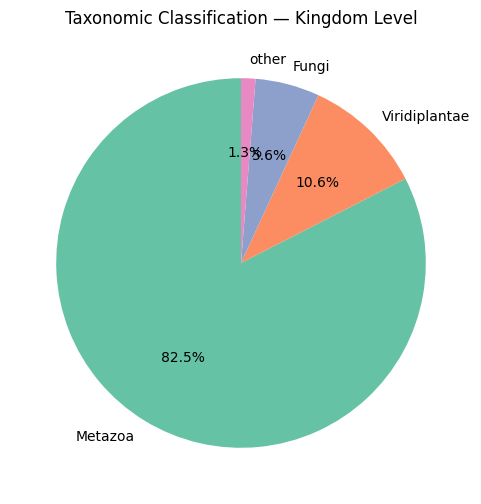

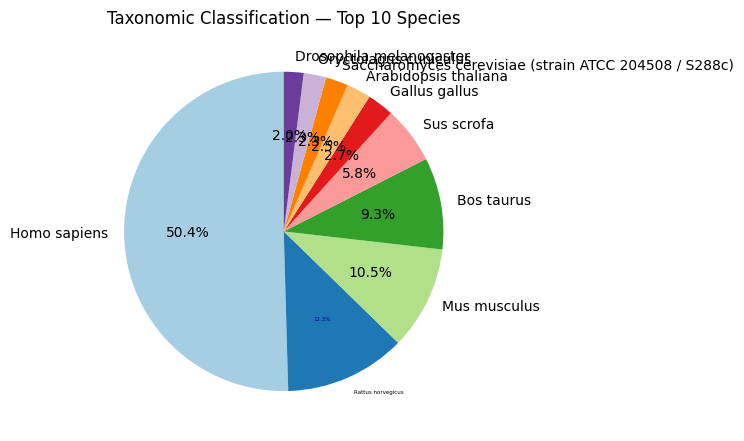

In [9]:
import matplotlib.pyplot as plt


# ---------- Kingdom Level ----------
kingdom_counts = tsv['kingdom'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(kingdom_counts.values, labels=kingdom_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Taxonomic Classification — Kingdom Level')
plt.show()

# ---------- Species Level ----------
# Show only top 10 most represented species for clarity

# Call plt.pie and capture the returned text objects
# 'patches' (slices), 'texts' (outer labels), 'autotexts' (inner percentages)
patches, texts, autotexts = plt.pie(species_counts.values, labels=species_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Paired'))

# --- Action: Manually Adjust Font Size for the Second Slice (index 1) ---

# Define the smaller font size
SMALL_FONT_SIZE = 4

# 1. Adjust the font size for the second slice's outer label (the species name)
# The second slice is at index 1 of the 'texts' list.
texts[1].set_fontsize(SMALL_FONT_SIZE)

# 2. Adjust the font size for the second slice's inner percentage
# The second slice is at index 1 of the 'autotexts' list.
autotexts[1].set_fontsize(SMALL_FONT_SIZE)

# Optional: Add a subtle styling cue for clarity
autotexts[1].set_color('darkblue')


plt.title('Taxonomic Classification — Top 10 Species')
plt.tight_layout() # Adjust layout for a cleaner look
plt.show()
